In [1]:
from functools import partial

import matplotlib.pyplot as plt
import numpy as np

import cupy as cp

from superfv import HydroSolver, TimeIntegrator, ics, BC, MUSCL_SlopeLimiter
from spd.sdfb_simulator import SDFB_Simulator
from spd.finite_volume.muscl import Slope_limiter as spd_muscl_limiter

In [2]:
N = 192
T = 1.95

In [3]:
def gravity(idx, u, *, xp):
    gx = 0.0
    gy = 1.0
    out = xp.zeros_like(u)
    out[idx("mx")] = u[idx("rho")] * gx
    out[idx("my")] = u[idx("rho")] * gy
    out[idx("E")] = u[idx("mx")] * gx + u[idx("my")] * gy
    return out


sim_fv = HydroSolver(
    ic=partial(ics.rayleigh_taylor, gamma=5 / 3, P0=1.0),
    gamma=5 / 3,
    source=gravity,
    xlims=(0, 0.25),
    ylims=(0, 1),
    nx=N // 4,
    ny=N,
    bcy=(BC.REFLECTIVE, BC.REFLECTIVE),
    p=1,
    nu=1e-3,
    CFL=0.8,
    use_MUSCL=True,
    use_SED=False,
    MUSCL_limiter=MUSCL_SlopeLimiter.MONCEN,
    cupy=True,
)

sim_fv.run(T, TimeIntegrator.MUSCL_HANCOCK)

SuperFV: 1916 steps | t=1.95e+00/1.95e+00, dt=4.13e-06 | rho_min=9.15e-01 | E_cons=9.91e+01 | wall=7.09e+00s (done)


In [4]:
def rayleigh_taylor(xy: np.ndarray, case: int, P0, gamma):
    x = xy[0]
    y = xy[1]

    yc = 0.5
    rho1 = 2.0
    rho2 = 1.0

    if case == 0:
        # density
        return np.where(y > yc, rho2, rho1)
    elif case == 1:
        # vx
        return np.zeros(x.shape)
    elif case == 2:
        # vy
        dv = np.sqrt(gamma * (P0 + rho1 * yc - P0 + 1) / rho1)
        return -0.025 * dv * np.cos(8 * np.pi * x)
    elif case == 4:
        # Pressure
        return np.where(y > yc, P0 + rho2 * y + (rho1 - rho2) * yc, P0 + rho1 * y)
    else:
        return np.zeros(x.shape)


sim_sd = SDFB_Simulator(
    N=(N // 4, N),
    xlim=(0.0, 0.25),
    ylim=(0.0, 1.0),
    BC=(
        ("periodic", "periodic"),  # x
        ("reflective", "reflective"),  # y
    ),
    init_fct=partial(rayleigh_taylor, P0=1.0, gamma=5 / 3),
    gamma=5 / 3,
    potential=True,
    scheme="FV",
    p=1,
    viscosity=True,
    nu=1e-3,
    time_integrator="rk1",
    cfl_coeff=0.8,
    riemann_solver_sd="hllc",  # SD high-order flux
    riemann_solver_fv="hllc",  # MUSCL fallback flux
    use_cupy=True,
)

# Shape is (ndim, Ny, Nx) in 2D, (ndim, Nz, Ny, Nx) in 3D.
sim_sd.dm.grad_phi = cp.zeros((sim_sd.ndim,) + sim_sd.dm.U_cv.shape[1:])
sim_sd.dm.grad_phi[sim_sd.dims["y"]] = -1.0

sim_sd.ho_scheme.slope_limiter = spd_muscl_limiter("moncen")

W_cv_initial = sim_sd.dm.asnumpy(sim_sd.dm.W_cv).copy()

sim_sd.perform_time_evolution(T)

t=1.95, steps taken 1916, time taken 14.246, bzcps = 0.001


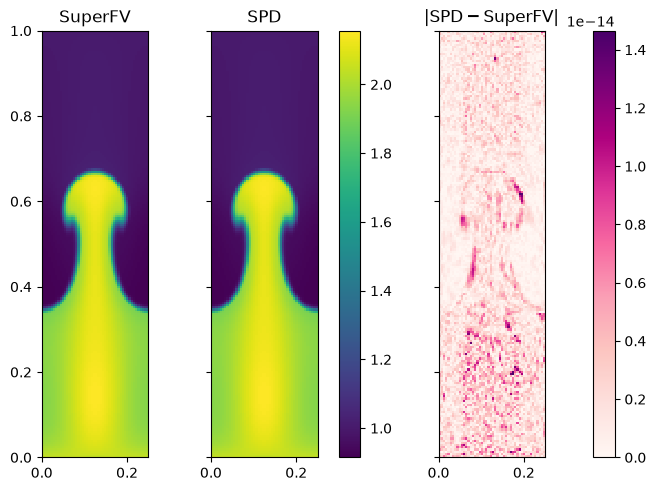

In [5]:
fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, constrained_layout=True)

for ax in axs:
    ax.set_aspect("equal")

x_sd = sim_sd.regular_faces()[0]
y_sd = sim_sd.regular_faces()[1]
z_sd = sim_sd.dm.W_cv[0]  # W_cv_initial[2]

x_fv, y_fv, _ = sim_fv.mesh.faces
z_fv = sim_fv.snapshot_history[-1].w[0, :, :, 0].T  # sim_fv.snapshot_history[0].w[2, :, :, 0].T

vmin = np.minimum(z_fv, z_sd).min().item()
vmax = np.maximum(z_fv, z_sd).max().item()

axs[0].set_title("SuperFV")
m0 = axs[0].pcolormesh(cp.asnumpy(x_fv), cp.asnumpy(y_fv), z_fv, vmin=vmin, vmax=vmax)

axs[1].set_title("SPD")
m1 = axs[1].pcolormesh(x_sd, y_sd, z_sd, vmin=vmin, vmax=vmax)
fig.colorbar(m1, ax=axs[1], pad=0.15)

axs[2].set_title(r"$|\text{SPD} - \text{SuperFV}|$")
m2 = axs[2].pcolormesh(x_sd, y_sd, np.abs(z_sd - z_fv), cmap="RdPu")
fig.colorbar(m2, ax=axs[2], pad=0.15)

fig.savefig("rayleigh-taylor_MUSCL-Hancock.png", dpi=300, bbox_inches="tight")